# Two-stage recommender: two-tower retrieval + LightGBM re-ranker

Every number here comes from `reports/metrics/reranker.json` and the SHAP sample written by the
DVC stages `retrieval` and `reranker` (`make experiments`).

* **Stage 1, retrieval.** The two-tower ensemble scores all ~3,300 candidates of a user and
  keeps the top N.
* **Stage 2, re-ranking.** A LightGBM LambdaRank model re-orders those N using ~20 features:
  the stage-1 scores themselves (two-tower, ALS, popularity, category affinity), video
  statistics from training, platform-wide engagement rates, and user × video affinities.

The re-ranker learns from the **validation week** (views from Aug 30 on, one per pair) of users
outside the fully observed matrix, with every feature computed from data before that date; its
hyperparameters are chosen on held-out validation users. The tune users' fully observed
reactions are used only to measure it, plus one clearly marked diagnostic (the cross-fitted
upper bound) that trains on them.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl

from recsys.viz import style


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dvc.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root(Path.cwd())
METRICS, FIGURES = ROOT / "reports/metrics", ROOT / "reports/figures"
report = json.loads((METRICS / "reranker.json").read_text(encoding="utf-8"))
shap_sample = pl.read_parquet(ROOT / "data/reranker/shap_sample.parquet")
METRIC = report["paired"]["two_tower"]["metric"]
TOP_N = report["retrieval"]["top_n"]
style.apply_style()


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / f"{name}.png")
    plt.show()
    plt.close(fig)

## 1. Does re-ranking help?

In [2]:
pl.DataFrame(
    [
        {
            "model": name,
            METRIC: m[METRIC],
            "95% CI": f"{m[f'{METRIC}_ci_low']:.3f} – {m[f'{METRIC}_ci_high']:.3f}",
            "recall_at_50": m["recall_at_50"],
            "coverage_at_10": m["coverage_at_10"],
            "popularity_pct_at_10": m["popularity_pct_at_10"],
        }
        for name, m in report["models"].items()
    ]
).sort(METRIC, descending=True)

model,ndcg_at_10,95% CI,recall_at_50,coverage_at_10,popularity_pct_at_10
str,f64,str,f64,f64,f64
"""two_tower""",0.298088,"""0.271 – 0.325""",0.035398,0.112714,0.489802
"""two_stage""",0.292876,"""0.267 – 0.318""",0.035816,0.08927,0.562582
"""als""",0.274005,"""0.246 – 0.302""",0.029958,0.223625,0.805465
"""two_stage_all_candidates""",0.258559,"""0.234 – 0.283""",0.029464,0.074542,0.543785


Each row compares a re-ranked ordering with ordering by the two-tower score alone, paired on
the same users:

* **validation users (logged views)**: users the ranker never saw in training or tuning,
  scored on the views the platform chose to show, like its own training data;
* **tune users**: the fully observed reactions, with the usual top-200 shortlist, and with the
  re-ranker ordering every candidate (no shortlist);
* **cross-fitted on tune users**: an upper bound for these features on fully observed data, from
  rankers trained on the *other* tune users' fully observed shortlists (a diagnostic only: it
  learns from tune labels).

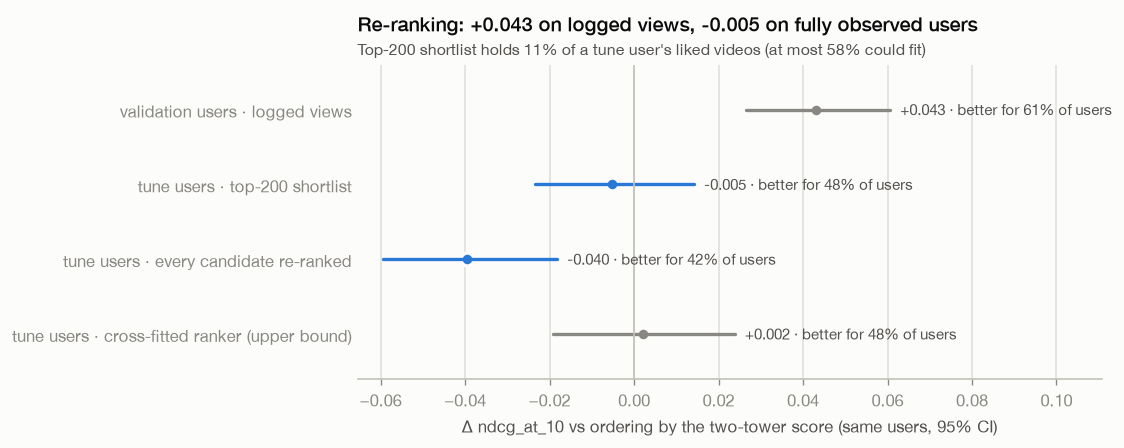

In [3]:
paired_tune = report["paired"]["two_tower"]["differences"]
rows = [
    {
        "label": "validation users · logged views",
        "highlight": False,
        **report["in_distribution"]["paired"]["differences"]["reranker"],
    },
    {"label": "tune users · top-200 shortlist", "highlight": True, **paired_tune["two_stage"]},
    {
        "label": "tune users · every candidate re-ranked",
        "highlight": True,
        **paired_tune["two_stage_all_candidates"],
    },
    {
        "label": "tune users · cross-fitted ranker (upper bound)",
        "highlight": False,
        **report["cross_fitted"]["paired"]["differences"]["two_stage_cross_fitted"],
    },
][::-1]
fig, ax = plt.subplots(figsize=(8, 3.4))
for position, row in enumerate(rows):
    color = style.PRIMARY if row["highlight"] else style.INK_MUTED
    ax.plot([row["ci_low"], row["ci_high"]], [position, position], color=color, linewidth=2)
    ax.scatter([row["mean"]], [position], s=60, color=color, edgecolors=style.SURFACE, linewidths=2)
    ax.annotate(
        f"{row['mean']:+.3f} · better for {row['win_rate']:.0%} of users",
        (row["ci_high"], position),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.axvline(0, color=style.BASELINE, linewidth=1)
ax.set_yticks(range(len(rows)), [row["label"] for row in rows])
ax.set_ylim(-0.6, len(rows) - 0.4)
ax.set_xlim(right=max(row["ci_high"] for row in rows) + 0.05)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel(f"Δ {METRIC} vs ordering by the two-tower score (same users, 95% CI)")
logged, observed = rows[-1]["mean"], rows[-2]["mean"]
style.add_title(
    ax,
    f"Re-ranking: {logged:+.3f} on logged views, {observed:+.3f} on fully observed users",
    f"Top-{TOP_N} shortlist holds {report['retrieval']['recall_at_n']:.0%} of a tune user's "
    f"liked videos (at most {report['retrieval']['recall_ceiling']:.0%} could fit)",
)
save(fig, "15_two_stage_paired")

## 2. How the re-ranker was tuned (held-out validation users)

Each configuration boosts until held-out NDCG stops improving for a while; the chosen
configuration has the best held-out score. The tune users played no part in this.

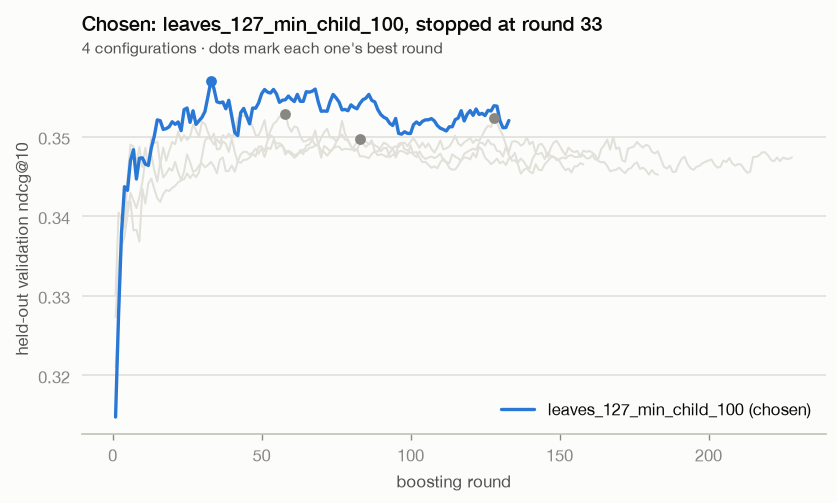

In [4]:
trials = report["ranker"]["trials"]
best_key = report["ranker"]["best"]["key"]
fig, ax = plt.subplots(figsize=(8, 4))
for trial in trials:
    is_best = trial["key"] == best_key
    ax.plot(
        np.arange(1, len(trial["curve"]) + 1),
        trial["curve"],
        color=style.PRIMARY if is_best else style.GRID,
        linewidth=style.LINE_WIDTH if is_best else 1.2,
        zorder=3 if is_best else 2,
        label=f"{trial['key']} (chosen)" if is_best else None,
    )
    ax.scatter(
        [trial["best_iteration"]],
        [trial["holdout_score"]],
        s=30,
        color=style.PRIMARY if is_best else style.INK_MUTED,
        zorder=4,
    )
ax.set_xlabel("boosting round")
ax.set_ylabel(f"held-out validation ndcg@{trials[0]['config']['eval_at']}")
ax.legend(loc="lower right")
best = report["ranker"]["best"]
style.add_title(
    ax,
    f"Chosen: {best_key}, stopped at round {best['best_iteration']}",
    f"{len(trials)} configurations · dots mark each one's best round",
)
save(fig, "16_reranker_training_curves")

## 3. What the re-ranker looks at (TreeSHAP on the tune shortlists)

A SHAP value is how much one feature moved one prediction away from the average; they add up
exactly to the model's score. A user's ranking only depends on differences between that
user's candidates, so the values are **centred within each user** first: features with one
value per user (`user_positive_rate`, `log_user_views`) then count only through their
interactions with other features. Caveats: LambdaRank scores are not probabilities, and
correlated features (the stage-one scores) share credit somewhat arbitrarily.

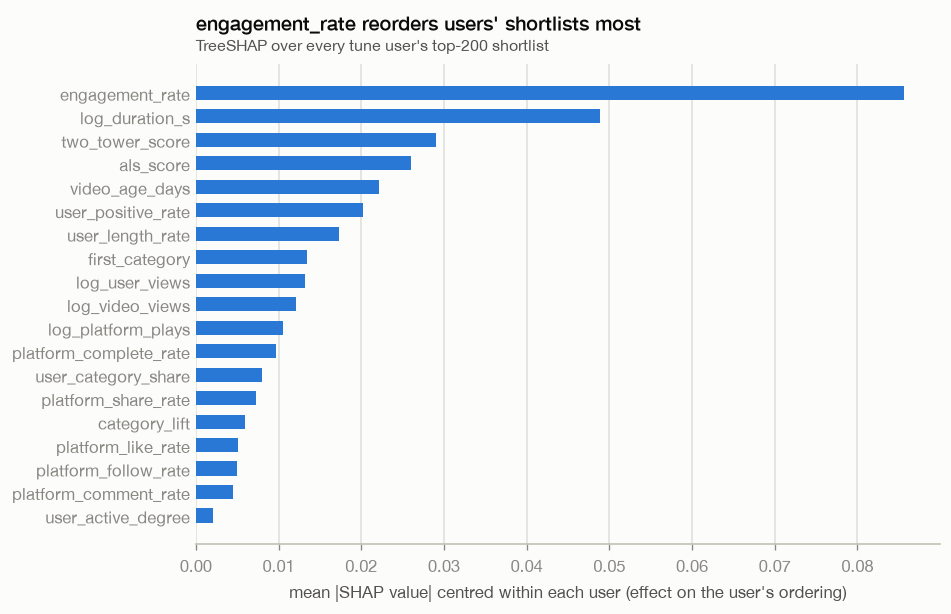

In [5]:
importance = pl.DataFrame(
    [{"feature": name, **values} for name, values in report["feature_importance"].items()]
).sort("mean_abs_within_user_shap")
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(
    importance["feature"], importance["mean_abs_within_user_shap"], color=style.PRIMARY, height=0.6
)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel("mean |SHAP value| centred within each user (effect on the user's ordering)")
top = importance.row(-1, named=True)
style.add_title(
    ax,
    f"{top['feature']} reorders users' shortlists most",
    f"TreeSHAP over every tune user's top-{TOP_N} shortlist",
)
save(fig, "17_reranker_shap_importance")

**Beeswarm.** Each dot is one (user, video) pair from the sample; its position is the
within-user SHAP value and its shade the feature's value (light = low, dark = high).

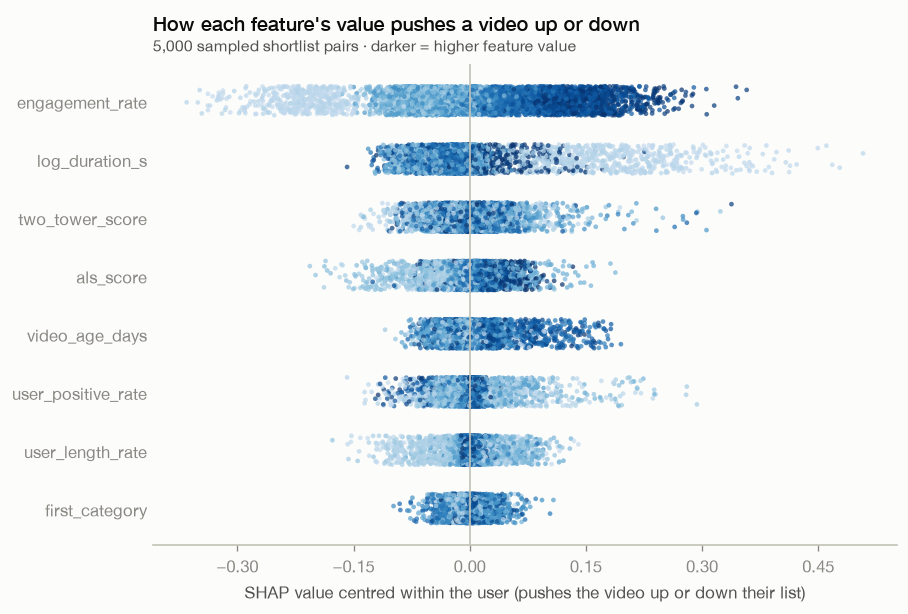

In [6]:
features = (
    importance.sort("mean_abs_within_user_shap", descending=True)["feature"].head(8).to_list()[::-1]
)
rng = np.random.default_rng(0)
ramp = plt.get_cmap("Blues")
fig, ax = plt.subplots(figsize=(8, 5.2))
for position, feature in enumerate(features):
    values = shap_sample[feature].cast(pl.Float64)
    shade = (values.rank() / values.len()).fill_null(0.5).to_numpy()
    ax.scatter(
        shap_sample[f"within_user_shap_{feature}"],
        position + rng.uniform(-0.25, 0.25, size=shap_sample.height),
        c=0.25 + 0.75 * shade,
        cmap=ramp,
        vmin=0,
        vmax=1,
        s=8,
        alpha=0.7,
        linewidths=0,
    )
ax.axvline(0, color=style.BASELINE, linewidth=1)
ax.set_yticks(range(len(features)), features)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_locator(mticker.MaxNLocator(7))
ax.set_xlabel("SHAP value centred within the user (pushes the video up or down their list)")
style.add_title(
    ax,
    "How each feature's value pushes a video up or down",
    f"{shap_sample.height:,} sampled shortlist pairs · darker = higher feature value",
)
save(fig, "18_reranker_shap_beeswarm")